In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor
import os
import fiona

In [2]:
meteo_doubs = gpd.read_file("../datasets_par_departement/meteo_doubs.geojson")

Dimensions du DataFrame :
(2572, 112)

Info sur les types de données et les valeurs manquantes :
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2572 entries, 0 to 2571
Columns: 112 entries, hex_id to geometry
dtypes: datetime64[ns](2), float64(102), geometry(1), int64(2), object(5)
memory usage: 2.2+ MB
None


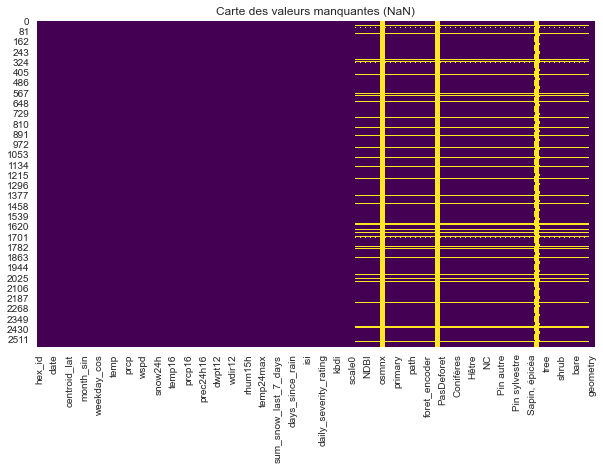


Nombre de valeurs manquantes (NaN) par colonne :
hex_id             0
id_meteo           0
duree_minutes      0
date               0
departement        0
                ... 
built            237
bare             237
snow_y           237
sinister         237
geometry           0
Length: 112, dtype: int64


In [3]:
print("Dimensions du DataFrame :")
print(meteo_doubs.shape)

print("\nInfo sur les types de données et les valeurs manquantes :")
print(meteo_doubs.info())

plt.figure(figsize=(10, 6))
sns.heatmap(meteo_doubs.isnull(), cbar=False, cmap='viridis')
plt.title("Carte des valeurs manquantes (NaN)")
plt.show()

print("\nNombre de valeurs manquantes (NaN) par colonne :")
print(meteo_doubs.isnull().sum())

In [4]:
nan_percentage = meteo_doubs.isnull().mean() * 100

cols_to_keep = nan_percentage[nan_percentage <= 80].index

meteo_doubs_drop = meteo_doubs[cols_to_keep]

print("\nDimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :")
print(meteo_doubs_drop.shape)

print("\nColonnes restantes après nettoyage :")
print(meteo_doubs_drop.columns)


Dimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :
(2572, 109)

Colonnes restantes après nettoyage :
Index(['hex_id', 'id_meteo', 'duree_minutes', 'date', 'departement',
       'centroid_lon', 'centroid_lat', 'hour_sin', 'hour_cos', 'month_sin',
       ...
       'tree', 'grass', 'crops', 'shrub', 'flooded', 'built', 'bare', 'snow_y',
       'sinister', 'geometry'],
      dtype='object', length=109)


In [5]:
meteo_doubs_drop = meteo_doubs_drop.dropna()

print("\nVérification des NaN après suppression des lignes dans meteo_doubs_drop :")
print(meteo_doubs_drop.isnull().sum())

print("\nDimensions du DataFrame meteo_doubs_drop après suppression des NaN :")
print(meteo_doubs_drop.shape)



Vérification des NaN après suppression des lignes dans meteo_doubs_drop :
hex_id           0
id_meteo         0
duree_minutes    0
date             0
departement      0
                ..
built            0
bare             0
snow_y           0
sinister         0
geometry         0
Length: 109, dtype: int64

Dimensions du DataFrame meteo_doubs_drop après suppression des NaN :
(2335, 109)


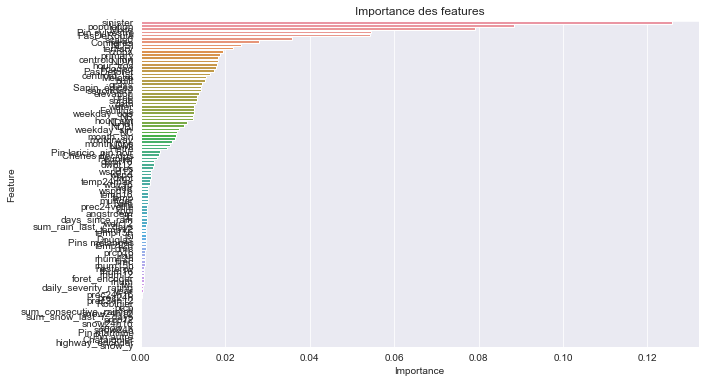

           Feature  Importance
100       sinister    0.125804
68      population    0.088357
79           Mixte    0.079134
87   Pin sylvestre    0.054638
62      PasDeRoute    0.054309
56          scale0    0.035786
75       Conifères    0.027945
60            NDSI    0.023808
66        tertiary    0.021869
94           crops    0.019481


In [6]:
X = meteo_doubs_drop.drop(columns=['duree_minutes', 'hex_id', 'id_meteo', 'date', 'departement', 'index', 'creneau', 'geometry'])
y = meteo_doubs_drop['duree_minutes']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importances = rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importance des features')
plt.show()

print(importance_df.head(10))

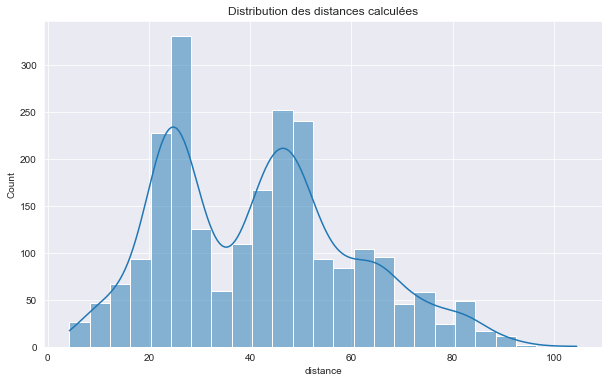

In [7]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

meteo_doubs_drop['distance'] = meteo_doubs_drop.apply(
    lambda row: haversine(row['centroid_lon'], row['centroid_lat'], 6.5, 47.5), axis=1
)

plt.figure(figsize=(10, 6))
sns.histplot(meteo_doubs_drop['distance'], kde=True)
plt.title('Distribution des distances calculées')
plt.show()

In [8]:
feature_importances = rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 15 des features les plus importantes :")
print(importance_df.head(15))

important_features = importance_df['Feature'].head(15).tolist()

if 'centroid_lon' not in important_features:
    important_features.append('centroid_lon')
if 'centroid_lat' not in important_features:
    important_features.append('centroid_lat')
if 'hour_cos' not in important_features:
    important_features.append('hour_cos')
if 'hour_sin' not in important_features:
    important_features.append('hour_sin')

X_selected = X[important_features]

print("\nFeatures utilisées pour l'entraînement du modèle :")
print(X_selected.columns)

Top 15 des features les plus importantes :
           Feature  Importance
100       sinister    0.125804
68      population    0.088357
79           Mixte    0.079134
87   Pin sylvestre    0.054638
62      PasDeRoute    0.054309
56          scale0    0.035786
75       Conifères    0.027945
60            NDSI    0.023808
66        tertiary    0.021869
94           crops    0.019481
64         primary    0.018864
0     centroid_lon    0.018258
57            NDVI    0.018244
3         hour_cos    0.018010
96         flooded    0.017813

Features utilisées pour l'entraînement du modèle :
Index(['sinister', 'population', 'Mixte', 'Pin sylvestre', 'PasDeRoute',
       'scale0', 'Conifères', 'NDSI', 'tertiary', 'crops', 'primary',
       'centroid_lon', 'NDVI', 'hour_cos', 'flooded', 'centroid_lat',
       'hour_sin'],
      dtype='object')


In [9]:
for col in X_selected.columns:
    print(f"{col} : {X_selected[col].unique()}")

sinister : [ 0.  2. 27.  1. 14. 20.  6.  4. 45. 10.  3. 24.  8. 33. 32. 18.  7. 29.
 55.  9. 15. 23. 12. 11. 26. 21.  5. 22. 44. 36. 16. 19. 13. 41.]
population : [5.59999381e+01 1.00000047e+01 1.69999873e+01 1.33299933e+03
 7.59999321e+01 1.47899921e+03 2.80000573e+01 1.19999880e+01
 9.90008429e+01 2.06000134e+02 4.69999687e+02 9.89998888e+01
 9.00012518e+00 1.51999995e+02 1.96399878e+03 8.00096812e+00
 2.00003529e+00 4.09999554e+01 1.00005127e+00 1.67299880e+03
 5.49999933e+01 3.00001119e+01 3.00001265e+01 9.99999035e+01
 6.72001076e+02 2.50000486e+01 3.23999670e+02 5.99999334e+00
 1.72000321e+02 6.70001238e+01 8.03000806e+02 2.59999834e+01
 7.59999501e+01 1.00007058e+00 2.30999704e+02 3.80007670e+01
 3.00003529e+00 3.29999600e+01 3.00002464e+00 2.80004122e+01
 1.89999788e+02 1.68999818e+02 5.00007923e+00 1.51999802e+02
 2.80000286e+01 6.70001618e+01 1.70999820e+02 5.09999722e+02
 5.00000466e+00 1.03999912e+02 6.40003083e+01 5.33000687e+02
 3.09999674e+01 3.69999707e+01 2.39999747e+0

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nÉvaluation du modèle :")
print(f"Mean Squared Error (MSE) : {mse}")
print(f"Mean Absolute Error (MAE) : {mae}")
print(f"R² (coefficient de détermination) : {r2}")
print(f"Root Mean Squared Error (RMSE) : {rmse}")


Évaluation du modèle :
Mean Squared Error (MSE) : 689.5535550321198
Mean Absolute Error (MAE) : 8.891905781584581
R² (coefficient de détermination) : 0.7640154108018066
Root Mean Squared Error (RMSE) : 26.259351763364606


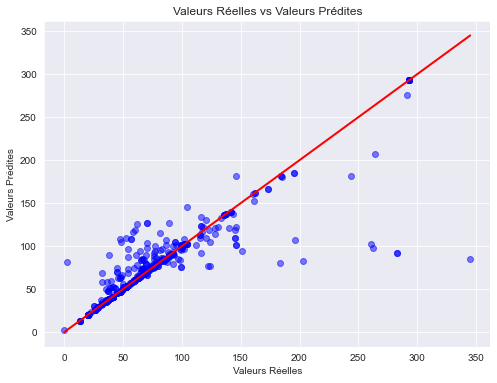

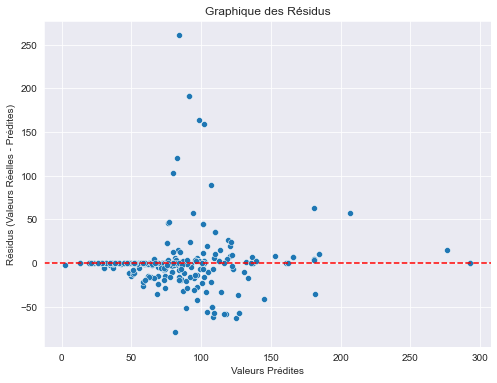

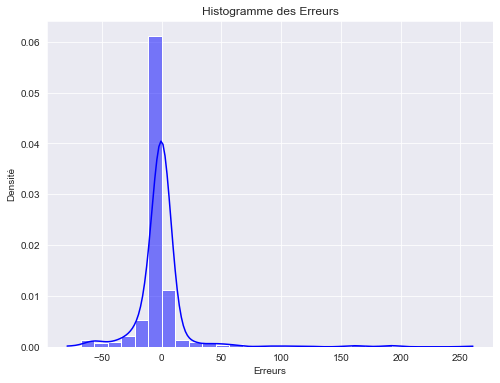

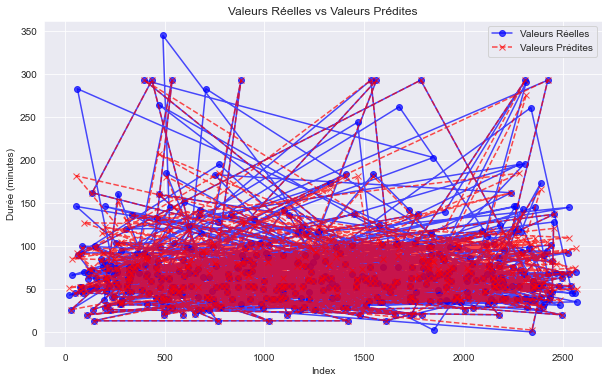

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)  # ligne parfaite
plt.title("Valeurs Réelles vs Valeurs Prédites")
plt.xlabel("Valeurs Réelles")
plt.ylabel("Valeurs Prédites")
plt.grid(True)
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Graphique des Résidus")
plt.xlabel("Valeurs Prédites")
plt.ylabel("Résidus (Valeurs Réelles - Prédites)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color='blue', stat='density')
plt.title("Histogramme des Erreurs")
plt.xlabel("Erreurs")
plt.ylabel("Densité")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label='Valeurs Réelles', color='blue', linestyle='-', marker='o', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Valeurs Prédites', color='red', linestyle='--', marker='x', alpha=0.7)
plt.title("Valeurs Réelles vs Valeurs Prédites")
plt.xlabel("Index")
plt.ylabel("Durée (minutes)")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
"""model = RandomForestRegressor()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Meilleurs paramètres : ", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_optimized = best_model.predict(X_test)

print("Optimized MSE:", mean_squared_error(y_test, y_pred_optimized))
print("Optimized MAE:", mean_absolute_error(y_test, y_pred_optimized))
print("Optimized R²:", r2_score(y_test, y_pred_optimized))"""

'model = RandomForestRegressor()\n\nparam_grid = {\n    \'n_estimators\': [100, 200, 300],\n    \'max_depth\': [None, 10, 20, 30],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4],\n    \'bootstrap\': [True, False]\n}\n\ngrid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)\ngrid_search.fit(X_train, y_train)\n\nprint("Meilleurs paramètres : ", grid_search.best_params_)\n\nbest_model = grid_search.best_estimator_\ny_pred_optimized = best_model.predict(X_test)\n\nprint("Optimized MSE:", mean_squared_error(y_test, y_pred_optimized))\nprint("Optimized MAE:", mean_absolute_error(y_test, y_pred_optimized))\nprint("Optimized R²:", r2_score(y_test, y_pred_optimized))'

In [13]:
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

print("MSE (GB):", mean_squared_error(y_test, y_pred_gb))
print("MAE (GB):", mean_absolute_error(y_test, y_pred_gb))
print("R² (GB):", r2_score(y_test, y_pred_gb))

MSE (GB): 1124.62796245075
MAE (GB): 19.789172900640818
R² (GB): 0.6151207316922915


In [14]:
mlp_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, activation='relu', solver='adam')
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

print("MSE (MLP):", mean_squared_error(y_test, y_pred_mlp))
print("MAE (MLP):", mean_absolute_error(y_test, y_pred_mlp))
print("R² (MLP):", r2_score(y_test, y_pred_mlp))

MSE (MLP): 1861.383299160258
MAE (MLP): 31.79022709238104
R² (MLP): 0.36298236737790357


In [15]:
"""residuals = y_test - y_pred_optimized

plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs Réelles (duree_minutes)")
plt.ylabel("Résidus (erreur)")
plt.title("Analyse des Résidus")
plt.show()"""

'residuals = y_test - y_pred_optimized\n\nplt.figure(figsize=(10, 6))\nplt.scatter(y_test, residuals, alpha=0.5)\nplt.axhline(0, color=\'red\', linestyle=\'--\')\nplt.xlabel("Valeurs Réelles (duree_minutes)")\nplt.ylabel("Résidus (erreur)")\nplt.title("Analyse des Résidus")\nplt.show()'

In [16]:
"""importances = best_model.feature_importances_
feature_names = X_train.columns
sorted_indices = importances.argsort()

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_indices)), importances[sorted_indices], align='center')
plt.yticks(range(len(sorted_indices)), feature_names[sorted_indices])
plt.xlabel("Importance des Features")
plt.title("Feature Importances")
plt.show()"""

'importances = best_model.feature_importances_\nfeature_names = X_train.columns\nsorted_indices = importances.argsort()\n\nplt.figure(figsize=(10, 6))\nplt.barh(range(len(sorted_indices)), importances[sorted_indices], align=\'center\')\nplt.yticks(range(len(sorted_indices)), feature_names[sorted_indices])\nplt.xlabel("Importance des Features")\nplt.title("Feature Importances")\nplt.show()'

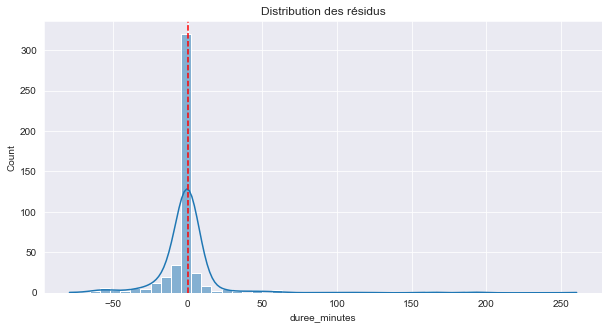

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution des résidus")
plt.show()

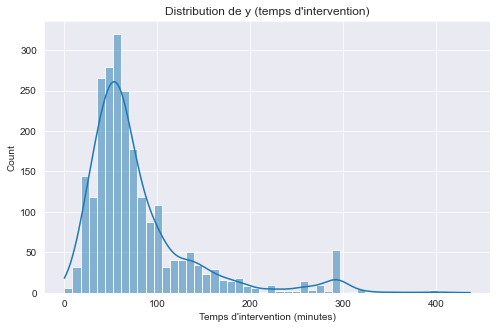

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution de y (temps d'intervention)")
plt.xlabel("Temps d'intervention (minutes)")
plt.show()

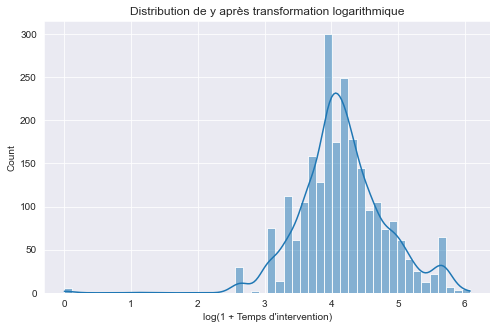

In [19]:
y_log = np.log1p(y)

plt.figure(figsize=(8,5))
sns.histplot(y_log, bins=50, kde=True)
plt.title("Distribution de y après transformation logarithmique")
plt.xlabel("log(1 + Temps d'intervention)")
plt.show()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_log, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    bootstrap=True,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_log = rf.predict(X_test)
mse_log = mean_squared_error(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

print(f"Log-MSE: {mse_log:.4f}")
print(f"Log-MAE: {mae_log:.4f}")
print(f"Log-R²: {r2_log:.4f}")

Log-MSE: 0.0641
Log-MAE: 0.0878
Log-R²: 0.8325


In [21]:
y_pred = np.expm1(y_pred_log)

y_test_actual = np.expm1(y_test)

mse_actual = mean_squared_error(y_test_actual, y_pred)
mae_actual = mean_absolute_error(y_test_actual, y_pred)
r2_actual = r2_score(y_test_actual, y_pred)

print(f"Actual-MSE: {mse_actual:.4f}")
print(f"Actual-MAE: {mae_actual:.4f}")
print(f"Actual-R²: {r2_actual:.4f}")

Actual-MSE: 731.8421
Actual-MAE: 8.3236
Actual-R²: 0.7495


In [22]:
"""param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score MSE (log) : {-grid_search.best_score_:.4f}")"""

'param_grid = {\n    \'n_estimators\': [100, 200, 300, 400],\n    \'max_depth\': [None, 10, 20, 30],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4],\n    \'bootstrap\': [True, False]\n}\n\nrf = RandomForestRegressor(\n    random_state=42\n)\n\ngrid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring=\'neg_mean_squared_error\')\n\ngrid_search.fit(X_train, y_train)\n\nprint(f"Meilleurs paramètres : {grid_search.best_params_}")\nprint(f"Meilleur score MSE (log) : {-grid_search.best_score_:.4f}")'

In [23]:
best_rf = RandomForestRegressor(
    bootstrap=True,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=400,
    random_state=42
)

best_rf.fit(X_train, y_train)

y_pred_log = best_rf.predict(X_test)

log_mse = mean_squared_error(y_test, y_pred_log)
log_mae = mean_absolute_error(y_test, y_pred_log)
log_r2 = r2_score(y_test, y_pred_log)
y_pred_actual = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)

actual_mse = mean_squared_error(y_test_actual, y_pred_actual)
actual_mae = mean_absolute_error(y_test_actual, y_pred_actual)
actual_r2 = r2_score(y_test_actual, y_pred_actual)

print(f"Log-MSE: {log_mse:.4f}")
print(f"Log-MAE: {log_mae:.4f}")
print(f"Log-R²: {log_r2:.4f}")
print(f"Actual-MSE: {actual_mse:.4f}")
print(f"Actual-MAE: {actual_mae:.4f}")
print(f"Actual-R²: {actual_r2:.4f}")

Log-MSE: 0.0642
Log-MAE: 0.0876
Log-R²: 0.8323
Actual-MSE: 729.3078
Actual-MAE: 8.3167
Actual-R²: 0.7504


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model = HistGradientBoostingRegressor(max_iter=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R²: {r2}")

Mean Squared Error (MSE): 682.3781544133144
Mean Absolute Error (MAE): 9.30702887874001
R²: 0.7664710343788359


In [25]:
param_grid = {
    'max_iter': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_bins': [255, 512]
}

model = HistGradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres : ", grid_search.best_params_)
print("Meilleur score MSE (négatif) : ", grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred_optimized = best_model.predict(X_test)

mse_optimized = mean_squared_error(y_test, y_pred_optimized)
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)

print(f"Optimized Mean Squared Error (MSE): {mse_optimized}")
print(f"Optimized Mean Absolute Error (MAE): {mae_optimized}")
print(f"Optimized R²: {r2_optimized}")

Fitting 3 folds for each of 162 candidates, totalling 486 fits


/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
243 fits failed out of a total of 486.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
243 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py", line 638, in _validate_params
    

Meilleurs hyperparamètres :  {'learning_rate': 0.05, 'max_bins': 255, 'max_depth': None, 'max_iter': 300, 'min_samples_leaf': 10}
Meilleur score MSE (négatif) :  -798.0132743969369
Optimized Mean Squared Error (MSE): 644.4682156726458
Optimized Mean Absolute Error (MAE): 7.118529372928206
Optimized R²: 0.7794448799271032


In [33]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_model = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    rf_model, param_distributions=param_dist,
    n_iter=200, scoring='neg_mean_squared_error',
    cv=3, verbose=2, random_state=42, n_jobs=-1
)

random_search.fit(X_selected, y)

print("Meilleurs hyperparamètres trouvés :", random_search.best_params_)
print("Meilleur score MSE (négatif) :", random_search.best_score_)

Fitting 3 folds for each of 200 candidates, totalling 600 fits
Meilleurs hyperparamètres trouvés : {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Meilleur score MSE (négatif) : -797.513019153275


In [32]:
best_rf_model = RandomForestRegressor(
    n_estimators=400,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=30,
    random_state=42
)

best_rf_model.fit(X_selected, y)

y_pred = best_rf_model.predict(X_selected)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MSE :", mse)
print("MAE :", mae)
print("R² :", r2)

MSE : 74.63883141646672
MAE : 2.732694291808366
R² : 0.9791697251886718


In [28]:
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'criterion': ['squared_error', 'absolute_error']
}

rf_model = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    rf_model, param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_selected, y)

print("Meilleurs hyperparamètres trouvés :", grid_search.best_params_)
print("Meilleur score MSE (négatif) :", grid_search.best_score_)

best_rf_model = RandomForestRegressor(
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
    min_samples_split=grid_search.best_params_['min_samples_split'],
    max_features=grid_search.best_params_['max_features'],
    bootstrap=grid_search.best_params_['bootstrap'],
    criterion=grid_search.best_params_['criterion'],
    random_state=42
)

best_rf_model.fit(X_selected, y)

y_pred = best_rf_model.predict(X_selected)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MSE :", mse)
print("MAE :", mae)
print("R² :", r2)

Fitting 3 folds for each of 1152 candidates, totalling 3456 fits


KeyboardInterrupt: 